### SetUp

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [49]:
!ls -al /content/drive/MyDrive/Data/B5_C2_D1_4492_4499_trimmed_resized

total 353540
-rw------- 1 root root 362003755 Sep  9 09:32 B5_C2_D1_4492_4499_trimmed_resized.mp4
drwx------ 5 root root      4096 Sep  9 09:32 chunks
drwx------ 2 root root      4096 Sep  9 09:32 frames
drwx------ 2 root root      4096 Sep  9 09:26 .ipynb_checkpoints
drwx------ 2 root root      4096 Sep  9 09:37 sam_outputs_csv
drwx------ 2 root root      4096 Sep  9 09:37 sam_outputs_videos


In [3]:
!cp -r /content/drive/MyDrive/Data/B5_C2_D1_4492_4499_trimmed_resized /content/

YOLO + SAM Workflow for RealTIme Videos

Overview
The YOLO + SAM workflow is effective for short videos. However, for larger videos, a chunking approach is necessary to manage GPU memory constraints.

1. Split Large Videos into Chunks
To accommodate 15 GB GPU memory, long videos are split into smaller chunks of approximately 750 frames each. The chunking process involves:
  - Running YOLO detection on each frame
  - Skipping frames with other than exactly 2 pigs detected
  - Skipping frames with IoU ≥ 0.3 with the previous frame
  - Marking the start of a new chunk and writing frames until the chunk size is reached

2. Process Each Chunk
Each chunk is processed as follows:
  - Load Models: Load YOLO and SAM models.
  - Correct Distortion: Apply distortion correction to each frame using cv2.undistort.
  - Define Arena: Define the arena boundaries and compute the pixel-to-meter conversion factor based on a 5x5 meter square.

For each frame in the chunk:
  - YOLO Detection: Run YOLO on the first frame to detect pigs.
  - SAM Tracking: Use SAM to track pigs across frames.
  - Frame Processing:
    - Undistort the frame.
    - Draw the arena outline.
    - Overlay pig masks (dark pink).
    - Draw bounding boxes (blue), ID labels (red), and centers (green).
    - Convert pixel positions to meters.
    - Update and display distance traveled (white text).
    - Add a watermark (YOLO/SAM).
  - Save Output: Save the processed frame to the output video and the first 10 frames to a preview video.
  - Save Distances: Save the distances traveled to a CSV file.

In [11]:
!pip install -qU ultralytics

!gdown https://drive.google.com/uc?id=1YTbpI-m27oDJdGivKA1x01MA37Kv8_5- -O /content/pigs-yolov8-weights.zip
!unzip /content/pigs-yolov8-weights.zip -d /content

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 28.1 MB/s eta 0:00:00
Downloading...
From (original): https://drive.google.com/uc?id=1YTbpI-m27oDJdGivKA1x01MA37Kv8_5-
From (redirected): https://drive.google.com/uc?id=1YTbpI-m27oDJdGivKA1x01MA37Kv8_5-&confirm=t&uuid=fe5f8fd1-86dc-42f2-b2fc-5c6bbec3f10d
To: /content/pigs-yolov8-weights.zip
100% 169M/169M [00:04<00:00, 39.6MB/s]
Archive:  /content/pigs-yolov8-weights.zip
  inflating: /content/v9/labels.jpg  
  inflating: /content/v9/train_batch5040.jpg  
  inflating: /content/v9/results.png  
  inflating: /content/v9/confusion_matrix_normalized.png  
  inflating: /content/v9/confusion_matrix.png  
  inflating: /content/v9/train_batch1.jpg  
  inflating: /content/v9/PR_curve.png  
  inflating: /content/v9/P_curve.png  
  inflating: /content/v9/events.out.tfevents.1718383799.Manzar-PC.2885.0  
  inflating: /content/v9/val_batch1_labels.jpg  
  inflating: /content/v9/train_batch0.jpg  
  inflating: /content/v9/train_batch5042.jpg  
  

In [41]:
import cv2
import os
from tqdm import tqdm

# --- Input video path ---
video_path = "/content/B5_C2_D1_4492_4499_trimmed_resized/chunks/chunk_1_undist.mp4"

# --- Output directory for frames (fixed path) ---
output_dir = "/content/B5_C2_D1_4492_4499_trimmed_resized/frames"
os.makedirs(output_dir, exist_ok=True)

# --- Video capture ---
cap = cv2.VideoCapture(video_path)
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

# --- Frame extraction settings ---
break_condition = 3   # stop after saving this many frames
frame_num = 0

with tqdm(total=total_frames, desc="Extracting frames", unit="frame") as pbar:
    while frame_num < break_condition:
        ret, frame = cap.read()
        if not ret:
            break  # End of video

        frame_num += 1
        frame_filename = os.path.join(output_dir, f"frame_{frame_num:05d}.jpg")
        cv2.imwrite(frame_filename, frame)

        pbar.update(1)

cap.release()
print(f"✅ Extracted {frame_num} frames into folder: {output_dir}")

Extracting frames:   0%|          | 3/750 [00:00<00:08, 83.97frame/s]

✅ Extracted 3 frames into folder: /content/B5_C2_D1_4492_4499_trimmed_resized/frames


In [43]:
!ls -al /content/B5_C2_D1_4492_4499_trimmed_resized/frames

total 1328
drwxr-xr-x 2 root root   4096 Sep  9 09:31 .
drwx------ 5 root root   4096 Sep  9 09:31 ..
-rw-r--r-- 1 root root 378438 Sep  9 09:31 frame_00001.jpg
-rw-r--r-- 1 root root 480894 Sep  9 09:31 frame_00002.jpg
-rw-r--r-- 1 root root 487077 Sep  9 09:31 frame_00003.jpg


In [31]:
# !rm -rf /content/B5_C2_D1_4492_4499_trimmed_resized/frames

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
🎥 Video info: 1280x972 @ 12 FPS
📊 Total frames: 5394

▶️ Started new chunk 1: /content/B5_C2_D1_4492_4499_trimmed_resized/chunks/chunk_1.mp4
📌 Start frame: 1
🐷 Pigs detected: 2
   Pig 1 BBX: (948, 596), (1198, 747)
   Pig 2 BBX: (904, 719), (1181, 866)
🔗 IoU between pigs: 0.092


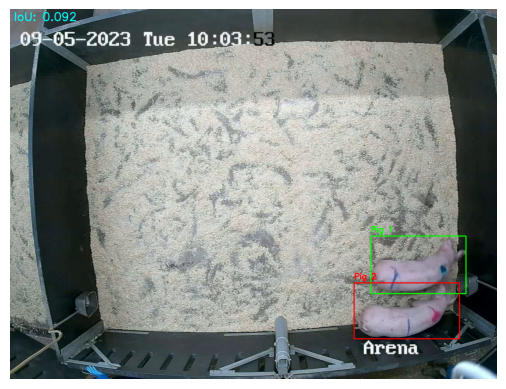

Chunk 1: 100%|██████████| 750/750 [00:36<00:00, 20.37frame/s]


🏁 End frame: 833


▶️ Started new chunk 2: /content/B5_C2_D1_4492_4499_trimmed_resized/chunks/chunk_2.mp4
📌 Start frame: 834
🐷 Pigs detected: 2
   Pig 1 BBX: (450, 67), (791, 193)
   Pig 2 BBX: (392, 69), (524, 363)
🔗 IoU between pigs: 0.127


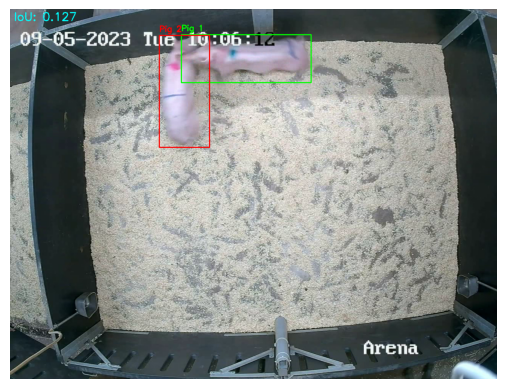

Chunk 2: 100%|██████████| 750/750 [00:38<00:00, 19.68frame/s]


🏁 End frame: 1658


▶️ Started new chunk 3: /content/B5_C2_D1_4492_4499_trimmed_resized/chunks/chunk_3.mp4
📌 Start frame: 1659
🐷 Pigs detected: 2
   Pig 1 BBX: (1004, 707), (1202, 854)
   Pig 2 BBX: (806, 622), (1031, 794)
🔗 IoU between pigs: 0.035


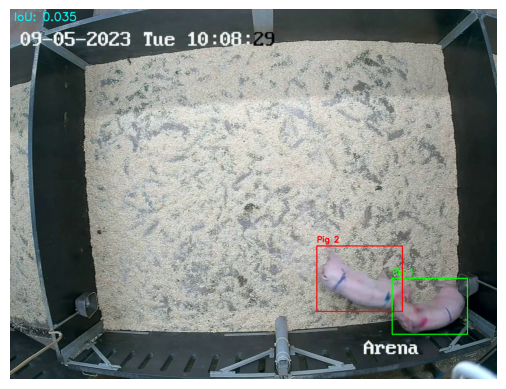

Chunk 3: 100%|██████████| 750/750 [00:42<00:00, 17.80frame/s]


🏁 End frame: 2622


▶️ Started new chunk 4: /content/B5_C2_D1_4492_4499_trimmed_resized/chunks/chunk_4.mp4
📌 Start frame: 2623
🐷 Pigs detected: 2
   Pig 1 BBX: (589, 90), (819, 371)
   Pig 2 BBX: (610, 211), (746, 482)
🔗 IoU between pigs: 0.274


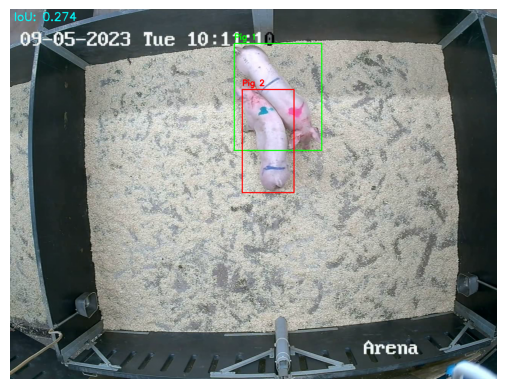

Chunk 4: 100%|██████████| 750/750 [00:40<00:00, 18.70frame/s]


🏁 End frame: 3521


▶️ Started new chunk 5: /content/B5_C2_D1_4492_4499_trimmed_resized/chunks/chunk_5.mp4
📌 Start frame: 3522
🐷 Pigs detected: 2
   Pig 1 BBX: (222, 255), (398, 551)
   Pig 2 BBX: (144, 224), (248, 512)
🔗 IoU between pigs: 0.090


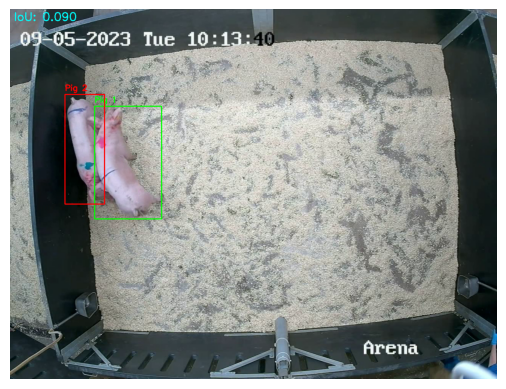

Chunk 5: 100%|██████████| 750/750 [00:49<00:00, 15.02frame/s]


🏁 End frame: 4678


▶️ Started new chunk 6: /content/B5_C2_D1_4492_4499_trimmed_resized/chunks/chunk_6.mp4
📌 Start frame: 4679
🐷 Pigs detected: 2
   Pig 1 BBX: (449, 518), (576, 817)
   Pig 2 BBX: (531, 600), (632, 914)
🔗 IoU between pigs: 0.166


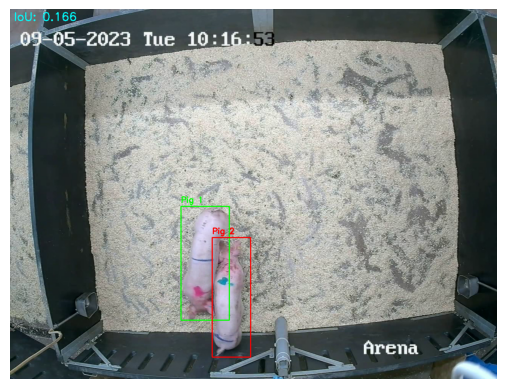

Chunk 6:  66%|██████▋   | 498/750 [00:31<00:15, 15.79frame/s]

🏁 End frame: 5394


✅ Splitting complete.


In [6]:
import cv2
import os
from tqdm import tqdm
from ultralytics import YOLO
import matplotlib.pyplot as plt

# --- Load YOLO model ---
yolo_model = YOLO("/content/v9/weights/best.pt")  # custom pig detector

# --- Input / Output ---
video_path = "/content/B5_C2_D1_4492_4499_trimmed_resized/B5_C2_D1_4492_4499_trimmed_resized.mp4"
output_dir = "/content/B5_C2_D1_4492_4499_trimmed_resized/chunks"
os.makedirs(output_dir, exist_ok=True)
plot_dir = os.path.join(output_dir, "plots")
os.makedirs(plot_dir, exist_ok=True)

# --- Open video ---
cap = cv2.VideoCapture(video_path)

# --- Video properties ---
fps = int(cap.get(cv2.CAP_PROP_FPS))
width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

chunk_size = 750
fourcc = cv2.VideoWriter_fourcc(*"mp4v")

print(f"🎥 Video info: {width}x{height} @ {fps} FPS")
print(f"📊 Total frames: {total_frames}")

# --- IoU function ---
def iou(box1, box2):
    x1, y1, x2, y2 = box1
    x3, y3, x4, y4 = box2

    xi1, yi1 = max(x1, x3), max(y1, y3)
    xi2, yi2 = min(x2, x4), min(y2, y4)
    inter_area = max(0, xi2 - xi1) * max(0, yi2 - yi1)

    box1_area = (x2 - x1) * (y2 - y1)
    box2_area = (x4 - x3) * (y4 - y3)
    union_area = box1_area + box2_area - inter_area
    return inter_area / union_area if union_area != 0 else 0

# --- Chunk splitting with YOLO filtering ---
chunk_index = 1
frame_count = 0
out = None
pbar = None
chunk_start_frame = None

while True:
    ret, frame = cap.read()
    if not ret:
        break

    current_frame_num = int(cap.get(cv2.CAP_PROP_POS_FRAMES))

    # Run YOLO detection
    results = yolo_model(frame, verbose=False)[0]

    # Extract bounding boxes for pigs
    pigs = [box.xyxy[0].tolist() for box in results.boxes]

    # --- Check conditions ---
    if len(pigs) == 2:
        iou_value = iou(pigs[0], pigs[1])  # compute IoU for this frame
        if iou_value < 0.3:  # avoid overlapping pigs
            # Start new chunk if needed
            if frame_count % chunk_size == 0:
                if out:
                    out.release()
                    pbar.close()
                    print(f"🏁 End frame: {chunk_end_frame}\n")

                chunk_name = os.path.join(output_dir, f"chunk_{chunk_index}.mp4")
                out = cv2.VideoWriter(chunk_name, fourcc, fps, (width, height))

                # Store start frame number
                chunk_start_frame = current_frame_num
                chunk_end_frame = chunk_start_frame + chunk_size - 1

                # Print info
                print(f"\n▶️ Started new chunk {chunk_index}: {chunk_name}")
                print(f"📌 Start frame: {chunk_start_frame}")
                print(f"🐷 Pigs detected: {len(pigs)}")
                for i, bbx in enumerate(pigs, 1):
                    x1, y1, x2, y2 = map(int, bbx)
                    print(f"   Pig {i} BBX: ({x1}, {y1}), ({x2}, {y2})")
                print(f"🔗 IoU between pigs: {iou_value:.3f}")

                # --- Draw BBX and IoU on first frame ---
                frame_plot = frame.copy()
                colors = [(0,255,0),(0,0,255)]
                for i, bbx in enumerate(pigs):
                    x1, y1, x2, y2 = map(int, bbx)
                    cv2.rectangle(frame_plot, (x1, y1), (x2, y2), colors[i], 2)
                    cv2.putText(frame_plot, f'Pig {i+1}', (x1, y1-10),
                                cv2.FONT_HERSHEY_SIMPLEX, 0.7, colors[i], 2)
                cv2.putText(frame_plot, f'IoU: {iou_value:.3f}', (10,30),
                            cv2.FONT_HERSHEY_SIMPLEX, 1, (255,255,0), 2)

                # --- Save plot ---
                plot_path = os.path.join(plot_dir, f'chunk_{chunk_index}_first_frame.png')
                cv2.imwrite(plot_path, frame_plot)

                # --- Optional: display in notebook ---
                plt.imshow(cv2.cvtColor(frame_plot, cv2.COLOR_BGR2RGB))
                plt.axis('off')
                plt.show()

                pbar = tqdm(total=chunk_size, desc=f"Chunk {chunk_index}", unit="frame")
                chunk_index += 1

            out.write(frame)
            frame_count += 1
            pbar.update(1)

            # Update end frame as we go
            chunk_end_frame = current_frame_num
        else:
            continue  # Skip overlapping pigs
    else:
        continue  # Skip if not exactly 2 pigs

# --- Cleanup ---
if out:
    out.release()
    pbar.close()
    print(f"🏁 End frame: {chunk_end_frame}\n")

cap.release()
print("\n✅ Splitting complete.")

In [6]:
import cv2
import numpy as np
import os
from tqdm import tqdm  # progress bar

# --- Folder with chunks ---
video_folder = "/content/B5_C2_D1_4492_4499_trimmed_resized/chunks"

# --- Camera intrinsics ---
fx, fy = 800, 800
dist = np.array([-0.20, 0.05, 0.0, 0.0, 0.0], dtype=np.float32)

# --- Process all .mp4 files in folder ---
video_files = sorted([f for f in os.listdir(video_folder) if f.endswith(".mp4")])

for vid_name in video_files:
    video_path = os.path.join(video_folder, vid_name)
    out_path = os.path.join(video_folder, vid_name.replace(".mp4", "_undist.mp4"))

    print(f"\n🎬 Processing {vid_name} ...")

    cap = cv2.VideoCapture(video_path)
    ret, frame = cap.read()
    if not ret:
        print(f"❌ Could not read {vid_name}, skipping.")
        cap.release()
        continue

    h, w = frame.shape[:2]
    cx, cy = w // 2, h // 2
    K = np.array([[fx, 0, cx],
                  [0, fy, cy],
                  [0,  0,  1]], dtype=np.float32)

    fps = cap.get(cv2.CAP_PROP_FPS) or 30
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    out = cv2.VideoWriter(out_path, cv2.VideoWriter_fourcc(*"mp4v"), fps, (w, h))

    # reset video
    cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

    # --- Progress bar ---
    for _ in tqdm(range(total_frames), desc=f"   {vid_name}", unit="frame"):
        ret, frame = cap.read()
        if not ret:
            break
        undistorted = cv2.undistort(frame, K, dist, None, K)
        out.write(undistorted)

    cap.release()
    out.release()
    print(f"✅ Saved undistorted video: {out_path}")



🎬 Processing chunk_1.mp4 ...


   chunk_1.mp4: 100%|██████████| 750/750 [00:27<00:00, 27.72frame/s]


✅ Saved undistorted video: /content/B5_C2_D1_4492_4499_trimmed_resized/chunks/chunk_1_undist.mp4

🎬 Processing chunk_2.mp4 ...


   chunk_2.mp4: 100%|██████████| 750/750 [00:26<00:00, 28.00frame/s]


✅ Saved undistorted video: /content/B5_C2_D1_4492_4499_trimmed_resized/chunks/chunk_2_undist.mp4

🎬 Processing chunk_3.mp4 ...


...

✅ Saved undistorted video: /content/B5_C2_D1_4492_4499_trimmed_resized/chunks/chunk_4_undist.mp4

🎬 Processing chunk_5.mp4 ...


   chunk_5.mp4: 100%|██████████| 750/750 [00:27<00:00, 27.39frame/s]


✅ Saved undistorted video: /content/B5_C2_D1_4492_4499_trimmed_resized/chunks/chunk_5_undist.mp4

🎬 Processing chunk_6.mp4 ...


   chunk_6.mp4: 100%|██████████| 498/498 [00:19<00:00, 26.07frame/s]

✅ Saved undistorted video: /content/B5_C2_D1_4492_4499_trimmed_resized/chunks/chunk_6_undist.mp4


In [8]:
!ls /content/B5_C2_D1_4492_4499_trimmed_resized/chunks/*_undist.mp4

/content/B5_C2_D1_4492_4499_trimmed_resized/chunks/chunk_1_undist.mp4
/content/B5_C2_D1_4492_4499_trimmed_resized/chunks/chunk_2_undist.mp4
/content/B5_C2_D1_4492_4499_trimmed_resized/chunks/chunk_3_undist.mp4
/content/B5_C2_D1_4492_4499_trimmed_resized/chunks/chunk_4_undist.mp4
/content/B5_C2_D1_4492_4499_trimmed_resized/chunks/chunk_5_undist.mp4
/content/B5_C2_D1_4492_4499_trimmed_resized/chunks/chunk_6_undist.mp4


In [45]:
from ultralytics import YOLO
from ultralytics.models.sam import SAM2VideoPredictor
import cv2
import torch
import gc
import os
import pandas as pd
import numpy as np

# --- Load models ---
yolo_model = YOLO("/content/v9/weights/best.pt")
SAM_MODEL_PATH = "sam2.1_b.pt"
predictor = SAM2VideoPredictor(overrides={"model": SAM_MODEL_PATH})

# --- Arena corners (unsorted) ---
arena_corners = np.array([
  [153,115],
  [1207,34],
  [201,873],
  [1234,827]
], dtype=np.int32)

# --- Sort arena corners so they form a rectangle ---
def order_points(pts):
    rect = np.zeros((4, 2), dtype="float32")
    s = pts.sum(axis=1)
    diff = np.diff(pts, axis=1)

    rect[0] = pts[np.argmin(s)]      # top-left
    rect[2] = pts[np.argmax(s)]      # bottom-right
    rect[1] = pts[np.argmin(diff)]   # top-right
    rect[3] = pts[np.argmax(diff)]   # bottom-left
    return rect.astype(int)

arena_corners = order_points(arena_corners)

# Arena scaling
arena_width_px = np.linalg.norm(arena_corners[0] - arena_corners[1])
arena_height_px = np.linalg.norm(arena_corners[1] - arena_corners[2])
pixels_per_side = (arena_width_px + arena_height_px) / 2.0
meters_per_pixel = 5.0 / pixels_per_side

# --- Input / output ---
video_folder = "/content/B5_C2_D1_4492_4499_trimmed_resized/chunks"
video_files = sorted([os.path.join(video_folder, f)
                      for f in os.listdir(video_folder) if f.endswith("_undist.mp4")])

output_video_folder = "/content/sam_outputs_videos"
output_csv_folder = "/content/sam_outputs_csv"
os.makedirs(output_video_folder, exist_ok=True)
os.makedirs(output_csv_folder, exist_ok=True)

# --- Ask user which video(s) to run ---
print("\nAvailable videos:")
for idx, v in enumerate(video_files, 1):
    print(f" {idx}: {os.path.basename(v)}")

choice = int(input("\nEnter -1 for all, 0 for none, or 1–7 for specific video: "))

if choice == 0:
    print("❌ No video selected. Exiting.")
    exit()

if choice == -1:
    selected_videos = video_files
else:
    if 1 <= choice <= len(video_files):
        selected_videos = [video_files[choice-1]]
    else:
        print(f"⚠️ Invalid choice ({choice}). Exiting.")
        exit()

# --- Process selected videos ---
for video_path in selected_videos:
    print(f"\n📹 Processing {video_path}...")

    cap = cv2.VideoCapture(video_path)
    ret, first_frame = cap.read()
    if not ret:
        print(f"❌ Could not read first frame of {video_path}")
        cap.release()
        continue

    # Run YOLO on first frame
    print("🔍 Running YOLO on first frame...")
    first_rgb = cv2.cvtColor(first_frame, cv2.COLOR_BGR2RGB)
    yolo_results = yolo_model(first_rgb)[0]
    last_yolo_bboxes = yolo_results.boxes.xyxy

    if len(last_yolo_bboxes) == 0:
        print(f"⚠️ No pigs detected in {video_path}, skipping.")
        cap.release()
        continue

    frame_height, frame_width = first_frame.shape[:2]
    fps = cap.get(cv2.CAP_PROP_FPS) or 30
    output_video_path = os.path.join(output_video_folder, os.path.basename(video_path))
    out = cv2.VideoWriter(output_video_path, cv2.VideoWriter_fourcc(*"mp4v"), fps, (frame_width, frame_height))

    # Output CSV + 10-frame preview video
    output_csv_path = os.path.join(output_csv_folder, os.path.basename(video_path).replace(".mp4", ".csv"))
    check_video_path = os.path.join(output_csv_folder, os.path.basename(video_path).replace(".mp4", "_check10.mp4"))
    check_out = cv2.VideoWriter(check_video_path, cv2.VideoWriter_fourcc(*"mp4v"), fps, (frame_width, frame_height))

    cap.release()

    # Tracking storage
    metadata = {i: {"x": [], "y": [], "dist": 0.0} for i in range(len(last_yolo_bboxes))}

    # Run SAM
    print("🎥 Running SAM tracking...")
    sam_stream = predictor(source=video_path, bboxes=last_yolo_bboxes, stream=True)

    for frame_id, result in enumerate(sam_stream):
        frame = result.orig_img
        annotated = frame.copy()

        # --- Arena red polygon ---
        cv2.polylines(annotated, [arena_corners], True, (0,0,255), 3)

        # --- SAM masks overlay ---
        if result.masks is not None:
            for mask in result.masks.data.cpu().numpy():
                mask = (mask * 255).astype(np.uint8)
                mask_colored = np.zeros_like(frame, dtype=np.uint8)
                mask_colored[:, :, 0] = 147
                mask_colored[:, :, 1] = 20
                mask_colored[:, :, 2] = 255
                blended = cv2.addWeighted(annotated, 1.0, mask_colored, 0.3, 0)
                annotated[mask > 0] = blended[mask > 0]

        # --- Bounding boxes + distances ---
        if result.boxes is not None:
            for obj_id, (bbox, cls) in enumerate(zip(result.boxes.xyxy, result.boxes.cls)):
                x1, y1, x2, y2 = bbox.cpu().numpy()
                cx, cy = (x1+x2)/2, (y1+y2)/2

                # Track movement
                metadata[obj_id]["x"].append(cx * meters_per_pixel)
                metadata[obj_id]["y"].append(cy * meters_per_pixel)
                if len(metadata[obj_id]["x"]) > 1:
                    dx = metadata[obj_id]["x"][-1] - metadata[obj_id]["x"][-2]
                    dy = metadata[obj_id]["y"][-1] - metadata[obj_id]["y"][-2]
                    metadata[obj_id]["dist"] += np.sqrt(dx**2 + dy**2)

                # Draw visuals
                cv2.rectangle(annotated, (int(x1), int(y1)), (int(x2), int(y2)), (255,0,0), 2)
                cv2.circle(annotated, (int(cx), int(cy)), 6, (0,255,0), -1)
                cv2.putText(annotated, f"Pig {obj_id}", (int(x1), int(y1) - 10),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0,0,255), 2, cv2.LINE_AA)

                # Distance text
                text = f"Pig {obj_id}: {metadata[obj_id]['dist']:.2f} m"
                cv2.putText(annotated, text, (frame_width-350, 40+30*obj_id),
                            cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255,255,255), 2, cv2.LINE_AA)

        # Watermark
        watermark_txt = "YOLO" if frame_id == 0 else "SAM"
        cv2.putText(annotated, watermark_txt, (20, frame_height - 20),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.9, (0,255,255), 2, cv2.LINE_AA)

        # Save
        if frame_id < 10:
            check_out.write(annotated)
        out.write(annotated)

    out.release()
    check_out.release()

    # Save CSV
    distances = [{"pig_id": pid, "distance_m": meta["dist"]} for pid, meta in metadata.items()]
    pd.DataFrame(distances).to_csv(output_csv_path, index=False)

    del sam_stream
    torch.cuda.empty_cache()
    gc.collect()

    print(f"✅ Finished {video_path}")
    print(f"   - Video saved to {output_video_path}")
    print(f"   - CSV saved to {output_csv_path}")
    print(f"   - Preview video saved to {check_video_path}")



Available videos:
 1: chunk_1_undist.mp4
 2: chunk_2_undist.mp4
 3: chunk_3_undist.mp4
 4: chunk_4_undist.mp4
 5: chunk_5_undist.mp4
 6: chunk_6_undist.mp4

Enter -1 for all, 0 for none, or 1–7 for specific video: 2

📹 Processing /content/B5_C2_D1_4492_4499_trimmed_resized/chunks/chunk_2_undist.mp4...
🔍 Running YOLO on first frame...

0: 512x640 2 pigs, 50.6ms
Speed: 2.5ms preprocess, 50.6ms inference, 1.6ms postprocess per image at shape (1, 3, 512, 640)
🎥 Running SAM tracking...

Ultralytics 8.3.196 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (Tesla T4, 15095MiB)
video 1/1 (frame 1/750) /content/B5_C2_D1_4492_4499_trimmed_resized/chunks/chunk_2_undist.mp4: 640x640 1 0, 1 1, 312.5ms
video 1/1 (frame 2/750) /content/B5_C2_D1_4492_4499_trimmed_resized/chunks/chunk_2_undist.mp4: 640x640 1 0, 1 1, 133.7ms
video 1/1 (frame 3/750) /content/B5_C2_D1_4492_4499_trimmed_resized/chunks/chunk_2_undist.mp4: 640x640 1 0, 1 1, 124.5ms
video 1/1 (frame 4/750) /content/B5_C2_D1_4492_4499_trimmed_resize

In [48]:
!cp -r /content/sam_outputs_csv /content/drive/MyDrive/Data/B5_C2_D1_4492_4499_trimmed_resized/
!cp -r /content/sam_outputs_videos /content/drive/MyDrive/Data/B5_C2_D1_4492_4499_trimmed_resized/